In [1]:
from src.dataset import load_dataset, preprocess

In [2]:
train_ds, val_ds, test_ds, info = load_dataset()

In [13]:
print(info)

tfds.core.DatasetInfo(
    name='oxford_iiit_pet',
    full_name='oxford_iiit_pet/4.0.0',
    description="""
    The Oxford-IIIT pet dataset is a 37 category pet image dataset with roughly 200
    images for each class. The images have large variations in scale, pose and
    lighting. All images have an associated ground truth annotation of breed and
    species. Additionally, head bounding boxes are provided for the training split,
    allowing using this dataset for simple object detection tasks. In the test
    split, the bounding boxes are empty.
    """,
    homepage='http://www.robots.ox.ac.uk/~vgg/data/pets/',
    data_dir='E:\\datasets\\oxford_iiit_pet\\4.0.0',
    file_format=tfrecord,
    download_size=773.52 MiB,
    dataset_size=773.68 MiB,
    features=FeaturesDict({
        'file_name': Text(shape=(), dtype=string),
        'head_bbox': BBoxFeature(shape=(4,), dtype=float32),
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=()

In [4]:
sample = next(iter(train_ds))
print(type(sample))
print(sample)

<class 'dict'>
{'file_name': <tf.Tensor: shape=(), dtype=string, numpy=b'japanese_chin_133.jpg'>, 'head_bbox': <tf.Tensor: shape=(4,), dtype=float32, numpy=array([0.2882883, 0.136    , 0.7447447, 0.398    ], dtype=float32)>, 'image': <tf.Tensor: shape=(333, 500, 3), dtype=uint8, numpy=
array([[[143, 140, 123],
        [138, 135, 118],
        [134, 131, 112],
        ...,
        [  4,   8,  11],
        [  4,   8,  11],
        [  5,   9,  10]],

       [[138, 135, 118],
        [142, 139, 120],
        [141, 138, 119],
        ...,
        [  4,   8,  11],
        [  4,   8,  11],
        [  4,   8,  11]],

       [[148, 143, 124],
        [140, 135, 116],
        [141, 138, 119],
        ...,
        [  3,   7,  10],
        [  4,   8,  11],
        [  4,   8,  11]],

       ...,

       [[ 89,  85,  74],
        [ 91,  84,  74],
        [ 92,  85,  77],
        ...,
        [172, 100,  86],
        [174, 104,  79],
        [173, 103,  91]],

       [[ 87,  84,  69],
        [ 85,  

In [3]:
import tensorflow as tf

In [6]:
image = sample["image"]
mask = sample["segmentation_mask"]
label = sample["label"]
print(image.shape)
print(mask.shape)
print(image.dtype)
print(mask.dtype)

(333, 500, 3)
(333, 500, 1)
<dtype: 'uint8'>
<dtype: 'uint8'>


In [7]:
import matplotlib.pyplot as plt

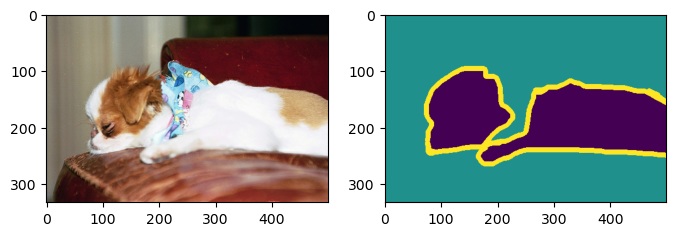

In [8]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(image)
plt.subplot(1,2,2)
plt.imshow(mask)

In [4]:
train_dataset = preprocess(train_ds, augmentation= True, training = True)
val_dataset = preprocess(val_ds, augmentation = False, training = False)

In [5]:
from src.model import build_unet

In [6]:
base_model = build_unet(input_shape = (96,96,3), num_classes = 3)

In [7]:
base_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 96, 96, 3)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 96, 96, 16)        │             432 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 96, 96, 16)        │              64 │ conv2d[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu (ReLU)                  │ (None, 96, 96, 16)        │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 96, 96, 16)        │           2,304 │ re_lu[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 96, 96, 16)        │              64 │ conv2d_1[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_1 (ReLU)                │ (None, 96, 96, 16)        │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 48, 48, 16)        │               0 │ re_lu_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 48, 48, 32)        │           4,608 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 48, 48, 32)        │             128 │ conv2d_2[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_2 (ReLU)                │ (None, 48, 48, 32)        │               0 │ batch_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 48, 48, 32)        │           9,216 │ re_lu_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 48, 48, 32)        │             128 │ conv2d_3[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_3 (ReLU)                │ (None, 48, 48, 32)        │               0 │ batch_normalization_3[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_1               │ (None, 24, 24, 32)        │               0 │ re_lu_3[0][0]              │
│ (MaxPooling2D)                │                           │               

 Total params: 2,163,875 (8.25 MB)

 Trainable params: 2,160,451 (8.24 MB)

 Non-trainable params: 3,424 (13.38 KB)

In [7]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
early_stop = EarlyStopping(
    monitor='val_loss',       
    patience=5,               
    restore_best_weights=True )

checkpoint = ModelCheckpoint(
    filepath='models/dice_unet.keras', 
    monitor='val_loss',      
    save_best_only=True,      
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=3, 
    min_lr=1e-5,
    verbose=1
)

In [14]:
base_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy', tf.keras.metrics.IoU(
            num_classes=3,
            target_class_ids=[0, 1, 2],
            sparse_y_true=True,
            sparse_y_pred=False,
            name="mean_iou"
        )]
)

In [ ]:
base_history = base_model.fit(
    train_dataset,
    validation_data = val_dataset,
    epochs=50,
    batch_size = 32,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8473 - loss: 0.3939 - mean_iou: 0.6285
Epoch 1: val_loss improved from 0.63492 to 0.44482, saving model to models/base_unet.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.8491 - loss: 0.3894 - mean_iou: 0.6313 - val_accuracy: 0.8290 - val_loss: 0.4448 - val_mean_iou: 0.5949 - learning_rate: 0.0010
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8580 - loss: 0.3669 - mean_iou: 0.6472
Epoch 2: val_loss improved from 0.44482 to 0.42355, saving model to models/base_unet.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.8576 - loss: 0.3672 - mean_iou: 0.6456 - val_accuracy: 0.8426 - val_loss: 0.4236 - val_mean_iou: 0.6160 - learning_rate: 0.0010
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8617 - loss: 0.3571 - mean_iou: 0.6532
Epoch 3: val_loss improved from 0.42355 to 0.37341, saving model to models/base_unet.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - accuracy: 0.864

In [13]:
print([m for m in dir(tf.keras.metrics) if "IoU" in m])

['BinaryIoU', 'IoU', 'MeanIoU', 'OneHotIoU', 'OneHotMeanIoU']


In [17]:
print("est")

est


In [18]:
from src.history import save_history
save_history(base_history, "history/base_history.pkl")

In [6]:
from src.train import *

In [7]:
dice_model = create_model()

In [6]:
dice_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 96, 96, 3)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 96, 96, 16)        │             432 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 96, 96, 16)        │              64 │ conv2d[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu (ReLU)                  │ (None, 96, 96, 16)        │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 96, 96, 16)        │           2,304 │ re_lu[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 96, 96, 16)        │              64 │ conv2d_1[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_1 (ReLU)                │ (None, 96, 96, 16)        │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 48, 48, 16)        │               0 │ re_lu_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 48, 48, 32)        │           4,608 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 48, 48, 32)        │             128 │ conv2d_2[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_2 (ReLU)                │ (None, 48, 48, 32)        │               0 │ batch_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 48, 48, 32)        │           9,216 │ re_lu_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 48, 48, 32)        │             128 │ conv2d_3[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_3 (ReLU)                │ (None, 48, 48, 32)        │               0 │ batch_normalization_3[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_1               │ (None, 24, 24, 32)        │               0 │ re_lu_3[0][0]              │
│ (MaxPooling2D)                │                           │               

 Total params: 2,163,875 (8.25 MB)

 Trainable params: 2,160,451 (8.24 MB)

 Non-trainable params: 3,424 (13.38 KB)

In [8]:
history_dice = train_model(dice_model, train_dataset, val_dataset)

Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6472 - loss: 0.5117 - mean_iou: 0.4013
Epoch 1: val_loss improved from None to 0.56362, saving model to models/dice_unet.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.7181 - loss: 0.4257 - mean_iou: 0.4766 - val_accuracy: 0.6886 - val_loss: 0.5636 - val_mean_iou: 0.3434 - learning_rate: 0.0010
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7934 - loss: 0.3162 - mean_iou: 0.5731
Epoch 2: val_loss improved from 0.56362 to 0.41805, saving model to models/dice_unet.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.8004 - loss: 0.3066 - mean_iou: 0.5821 - val_accuracy: 0.7355 - val_loss: 0.4180 - val_mean_iou: 0.4677 - learning_rate: 0.0010
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8173 - loss: 0.2813 - mean_iou: 0.6063
Epoch 3: val_loss improved from 0.41805 to 0.35369, saving model to models/dice_unet.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.8222 -

In [9]:
from src.history import save_history
save_history(history_dice, "history/dice_history1.pkl")

In [7]:
dice_cce_model = create_model()

In [8]:
history_dice_cce= train_model(dice_cce_model, train_dataset, val_dataset)

Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6209 - loss: 1.3609 - mean_iou: 0.3609
Epoch 1: val_loss improved from None to 1.28053, saving model to models/dice_cce_unet.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.7099 - loss: 1.1610 - mean_iou: 0.4455 - val_accuracy: 0.6995 - val_loss: 1.2805 - val_mean_iou: 0.3545 - learning_rate: 0.0010
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7954 - loss: 0.8759 - mean_iou: 0.5644
Epoch 2: val_loss did not improve from 1.28053
92/92 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.8061 - loss: 0.8345 - mean_iou: 0.5804 - val_accuracy: 0.6363 - val_loss: 1.9040 - val_mean_iou: 0.3646 - learning_rate: 0.0010
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8269 - loss: 0.7501 - mean_iou: 0.6132
Epoch 3: val_loss improved from 1.28053 to 1.13287, saving model to models/dice_cce_unet.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.8299 - loss: 0.7389 - mean_iou: 0.6174 - v

In [9]:
from src.history import save_history
save_history(history_dice_cce, "history/dice_cce_history.pkl")